# FX

This notebook illustrates some basic aspects of FX pricing, for instance, the definition of currency returns and the idea of UIP. It also implements a carry trade strategy.

## Load Packages and Extra Functions

In [1]:
using Printf, Dates, Statistics, JLD2

include("src/printmat.jl");

In [2]:
using Plots
default(size = (480,320),fmt = :png)

# Currency Returns

There are different ways to quote exchange rates, but this notebook uses $S$ to denote the number of domestic currency units (say, CHFs if you are a Swiss investor) to buy one unit of foreign currency (say, one USD). That is, we treat foreign currency as any other asset.

The next cell calculates the return of the following simple strategy:
- in $t=0$: buy foreign currency (at the price $S_0$) and lend it on foreign money market (at the safe rate $R_f^*$).
- in $t=1$: sell the foreign currency (at the price $S_1$)

Since the strategy is financed by borrowing on the domestic money market (at the rate $R_f$), the excess return is

$R^e = (1+R_f^*)S_1/S_0 - (1 + R_f)$

Notice that $R_f$ and $R_f^*$  are the safe rates over the investment period (for instance, one-month period). Conversion from annualized interest rates to these monthly rates is discussed under UIP (below).

### A Remark on the Code
The code uses `Rfˣ` to denote $R_f^*$ (since there is no easy way to get a subscript `f` or a superscript `*`).

In [3]:
S₀  = 1.2        #current spot FX rate, t=0
S₁  = 1.25       #spot FX rate in t=1
Rfˣ = 0.06       #safe ledning rate (foreign) between period 0 and 1
Rf  = 0.04       #safe domestic borrowing rate

Re = (1+Rfˣ)*S₁/S₀ - (1+Rf)

printblue("A simple example of how to calculate the excess return from investing in a foreign currency:\n")
xx = [S₀,Rf,Rfˣ,S₁,Re]
printmat(xx;rowNames=["S₀";"Rf";"Rfˣ";"S₁";"Currency excess return"])

A simple example of how to calculate the excess return from investing in a foreign currency:

S₀                         1.200
Rf                         0.040
Rfˣ                        0.060
S₁                         1.250
Currency excess return     0.064



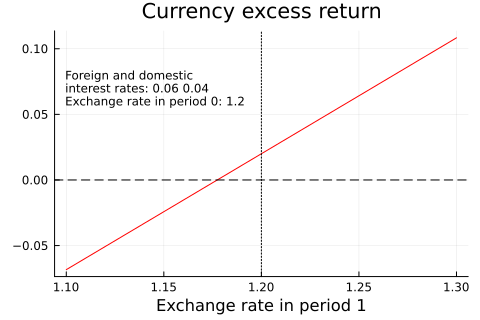

In [4]:
S₁_range = 1.1:0.01:1.3           #range of different possible exchange rates in t=1

Re = (1+Rfˣ)*S₁_range/S₀ .- (1+Rf)  #corresponding returns

txt = "Foreign and domestic \ninterest rates: $Rfˣ $Rf \nExchange rate in period 0: $S₀"

p1 = plot( S₁_range,Re,
           legend = nothing,
           linecolor = :red,
           title = "Currency excess return",
           xlabel = "Exchange rate in period 1",
           annotation = (1.1,0.07,text(txt,8,:left)) )
vline!([S₀],linecolor=:black,line=(:dot,1))
hline!([0],linecolor=:black,line=(:dash,1))
display(p1)

# Uncovered Interest Rate Parity (UIP)


UIP *assumes* that the expected future exchange rate ($\text{E}_0S_m$) is related to the current exchange rate and interest rates in such a way that the expected excess return of a foreign investment is zero.

In addition, interest rates are typically annualized (denoted $Y$ and $Y^*$ below). This means that the safe (gross) rate over an investment period of $m$ years (eg. $m=1/12$ for a month) is $(1+Y)^m$.

In [5]:
S₀  = 1.2                       #current spot FX rate
Y   = 0.04                      #annualized interest rates
Yˣ  = 0.06
m   = 1                         #investment period
ESₘ = S₀ * (1+Y)^m/(1+Yˣ)^m     #implies E(excess return) = 0

printblue("Expected future exchange rate $m years ahead according to UIP:\n")
xx = [S₀,Y,Yˣ,m,ESₘ]
printmat(xx;rowNames=["S₀";"Y";"Yˣ";"m";"UIP 'expectation' of Sₘ"])

Expected future exchange rate 1 years ahead according to UIP:

S₀                          1.200
Y                           0.040
Yˣ                          0.060
m                           1.000
UIP 'expectation' of Sₘ     1.177



# A Carry Trade Strategy

Means betting on high interest currencies and against low interest rate currencies.

## Load Data

The data needed is in a jld2 file.

In [6]:
(dN,Rx,fp,Rf,CurrNames) = load("Data/Fin2FxCarry2.jld2","dN","Rx","fp","Rf","CurrNames");

(T,n) = size(Rx)

(372, 9)

# Sorting on Forward Premia

The `m=3` currencies with the highest forward premia (interest rate differential) in $t-1$  are given portfolio weights `w_CT[t,i] = 1/m`. These are the investment currencies. The `m` currencies with the lowest forward premia in $t-1$ are given portfolio weights `w_CT[t,i] = -1/m`. These are the funding currencies.

### A Remark on the Code
- With `x = [9,7,8]`, the `rankPs(x)` function (see below) gives the output `[3,1,2]`. This says, for instance, that `7` is the lowest number (rank 1).
- `R.*w_CT` creates a `Txn` matrix, `sum(,dims=2)` sums across columns (for each row).

In [7]:
"""
    rankPs(x)

Calculates the ordinal rank of eack element in a vector `x`. As an aternative,
use `ordinalrank` from the `StatsBase.jl` package.

"""
rankPs(x) = invperm(sortperm(x))


"""
    ReturnCumPs(R,LogReturnQ=false)

Cumulate returns, with handling of NaNs (setting them to 0 in the cumulation).
Assumes net returns, but allows for log returns (`LogReturnQ=true`).

"""
function ReturnCum(R,LogReturnQ=false)

  vv = isunordered.(R)
  Rb = replace(z -> isunordered(z) ? 0.0 : z,R)    #do not cumulate NaNs
  P = LogReturnQ ? exp.(cumsum(Rb,dims=1)) : cumprod(1.0.+Rb,dims=1)     #P[1] = 1+R[1]
  P[vv] .= NaN               #put back the NaNs

  (n == 1) && (P = vec(P))                  #to vector, needed because of P[vvb:vvb,:]

  return P

end

ReturnCum

In [8]:
m = 3                #number of long/short positions

(wH,wL) = [zeros(T,n) for _ in 1:2]
for t in 2:T         #loop over periods, save portfolio returns
    #local r                          #local/global is needed in script
    r       = rankPs(-fp[t-1,:])      #yes, it should be (-1)fp
    wL[t,:] = (r.<=m)/m               #low interest rate currencies
    wH[t,:] = ((n-m+1).<=r)/m         #high interest rate currencies
end

RL      = sum(wL.*Rx,dims=2)
RH      = sum(wH.*Rx,dims=2)
REW     = mean(Rx,dims=2)                     #equally weighted
reCarry = log.(1.0.+RH)  - log.(1.0.+RL)
reEW    = log.(1.0.+REW) - log.(1.0.+Rf)


xx = [reCarry reEW][2:end,:]
(μ,σ) = (mean(xx,dims=1),std(xx,dims=1))
xut = vcat(μ*12*100,σ*sqrt(12)*100,μ*sqrt(12)./σ)
printmat(xut;rowNames=["mean","std","SR"])

mean     3.501    -0.367
std      7.923     7.840
SR       0.442    -0.047



In [9]:
μ

1×2 Matrix{Float64}:
 0.00291762  -0.000305948

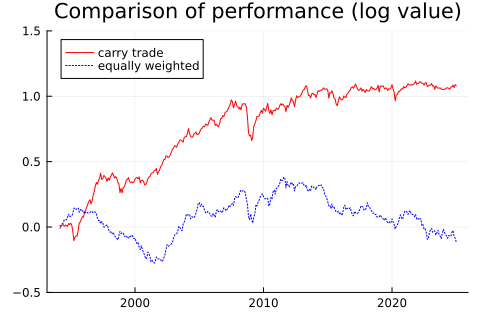

In [10]:

PL  = ReturnCum(RL)             #cumulatin returns, for the plot
PH  = ReturnCum(RH)
PEW = ReturnCum(REW)
PRf = ReturnCum(Rf)

xTicksLoc = [Date(2000),Date(2010),Date(2020)]
xTicksLab = Dates.format.(xTicksLoc,"Y")

p1 = plot( dN,hcat(log.(PH./PL),log.(PEW./PRf)),
           label = ["carry trade" "equally weighted"],
           linecolor = [:red :blue],
           linestyle = [:solid :dot],
           xticks = (xTicksLoc,xTicksLab),
           ylims = (-0.5,1.5),
           title = "Comparison of performance (log value)")
display(p1)